# PyTorch tensors and NumPy arrays

PyTorch tensors deliberately feel like NumPy arrays. Both represent rectangular collections of numbers and support familiar operations such as indexing, reshaping, broadcasting, and matrix multiplication.

PyTorch adds two capabilities needed for deep learning:

1. Tensors can run on accelerators such as NVIDIA CUDA and Intel XPU devices.
2. PyTorch can automatically calculate gradients for training models.

This notebook starts with the similarities and then explores those differences.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")

NumPy:  2.5.2
PyTorch: 2.13.0+cu130


## Choosing a device

The same notebook can run on an NVIDIA development machine or a classroom CPU. PyTorch calls the place where a tensor lives its **device**. We choose an accelerator when one is available and otherwise fall back to the CPU.

In [2]:
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
print(f"Using: {device}")

Using: cuda


## Creating arrays and tensors

The APIs and printed values are intentionally similar. One small difference is the default floating-point type: NumPy normally creates `float64` values, while PyTorch normally uses `float32`, which is faster and smaller for neural networks.

In [8]:
numpy_array = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)
torch_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)

print(numpy_array)
print(torch_tensor)
print(torch.from_numpy(numpy_array))

[[1. 2. 3.]
 [4. 5. 6.]]
tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([[1., 2., 3.],
        [4., 5., 6.]])


In [9]:
print("NumPy shape/dtype: ", numpy_array.shape, numpy_array.dtype)
print("PyTorch shape/dtype:", torch_tensor.shape, torch_tensor.dtype)
print("PyTorch device:     ", torch_tensor.device)

NumPy shape/dtype:  (2, 3) float32
PyTorch shape/dtype: torch.Size([2, 3]) torch.float32
PyTorch device:      cpu


PyTorch also provides creation functions corresponding closely to NumPy's.
As a general rule code from either can be swaped around with minimal changes.

In [11]:
print("NumPy zeros:\n", np.zeros((2, 3)))
print("PyTorch zeros:\n", torch.zeros((2, 3)))

print("NumPy range: ", np.arange(0, 10, 2))
print("PyTorch range:", torch.arange(0, 10, 2))

print("NumPy random: ", np.random.default_rng(42).random(3))
generator = torch.Generator().manual_seed(42)
print("PyTorch random:", torch.rand(3, generator=generator))

NumPy zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
PyTorch zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
NumPy range:  [0 2 4 6 8]
PyTorch range: tensor([0, 2, 4, 6, 8])
NumPy random:  [0.77395605 0.43887844 0.85859792]
PyTorch random: tensor([0.8823, 0.9150, 0.3829])


In [12]:
print("Second row:       ", torch_tensor[1])
print("First column:     ", torch_tensor[:, 0])
print("Values above 3:   ", torch_tensor[torch_tensor > 3])
print("Reshaped to 3 x 2:\n", torch_tensor.reshape(3, 2))

Second row:        tensor([4., 5., 6.])
First column:      tensor([1., 4.])
Values above 3:    tensor([4., 5., 6.])
Reshaped to 3 x 2:
 tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])


In [ ]:
offset = torch.tensor([10, 20, 30])

# The length-3 vector is broadcast across both rows.
print(torch_tensor + offset)

In [ ]:
print("Element-wise square:\n", torch_tensor**2)
print("Mean:", torch_tensor.mean())
print("Column sums:", torch_tensor.sum(axis=0))

weights = torch.tensor([[0.5], [1.0], [-0.5]])
print("Matrix multiplication:\n", torch_tensor @ weights)

In [ ]:
source_array = np.array([1.0, 2.0, 3.0], dtype=np.float32)
shared_tensor = torch.from_numpy(source_array)

shared_tensor[0] = 99
print("NumPy sees the change:", source_array)

back_to_numpy = shared_tensor.numpy()
print("Back to NumPy:       ", back_to_numpy)

In [ ]:
accelerated_tensor = torch_tensor.to(device)
result = accelerated_tensor @ weights.to(device)

print("Calculation device:", result.device)

# NumPy only accepts CPU data, so move the result back first.
result_as_numpy = result.cpu().numpy()
print(result_as_numpy)

## What tensors add: automatic differentiation

Training a neural network means adjusting parameters to reduce an error. PyTorch records operations on tensors whose `requires_grad` flag is enabled. Calling `.backward()` then applies the chain rule and stores each parameter's gradient in `.grad`.

For $y = x^2 + 3x$, calculus says $dy/dx = 2x + 3$. At $x = 2$, the gradient should therefore be 7.

x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3 * x
y.backward()

print("y:              ", y.item())
print("PyTorch dy/dx: ", x.grad.item())
print("Expected dy/dx:", 2 * x.item() + 3)

A slightly more realistic example computes the gradient of mean squared error for a one-parameter model $prediction = weight \times input$.

In [15]:
inputs = torch.tensor([1.0, 2.0, 3.0])
targets = torch.tensor([2.0, 4.0, 6.0])
weight = torch.tensor(1.0, requires_grad=True)

predictions = weight * inputs
loss = ((predictions - targets) ** 2).mean()
loss.backward()

print(f"Loss: {loss.item():.3f}")
print(f"Gradient for weight: {weight.grad.item():.3f}")

Loss: 4.667
Gradient for weight: -9.333


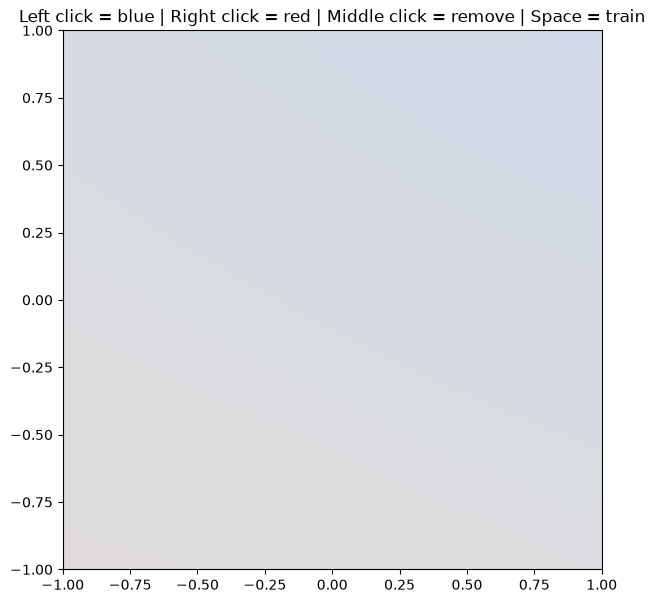

In [16]:
#

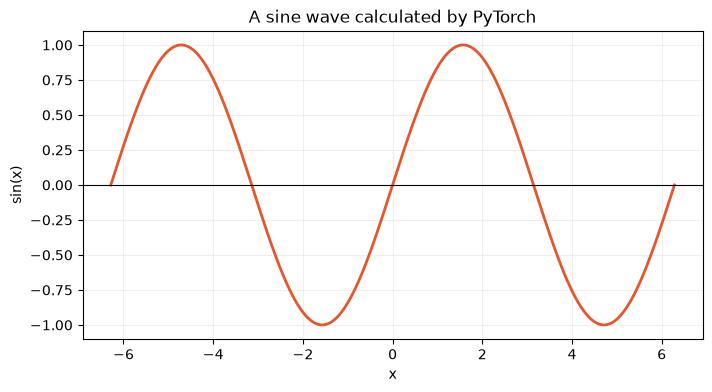

In [13]:
x_values = torch.linspace(-2 * torch.pi, 2 * torch.pi, 200, device=device)
y_values = torch.sin(x_values)

plt.figure(figsize=(8, 4))
plt.plot(
    x_values.detach().cpu().numpy(),
    y_values.detach().cpu().numpy(),
    color="#e4572e",
    linewidth=2,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("A sine wave calculated by PyTorch")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Write your solution here.